In [2]:
import matplotlib.pyplot as plt
import scipy.signal as sgn
import numpy as np
import mne

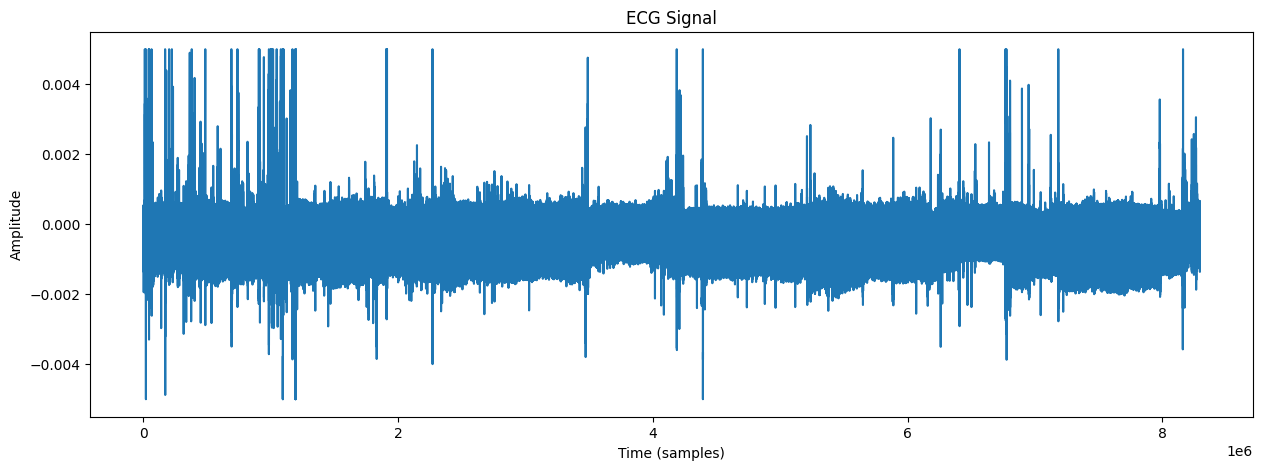

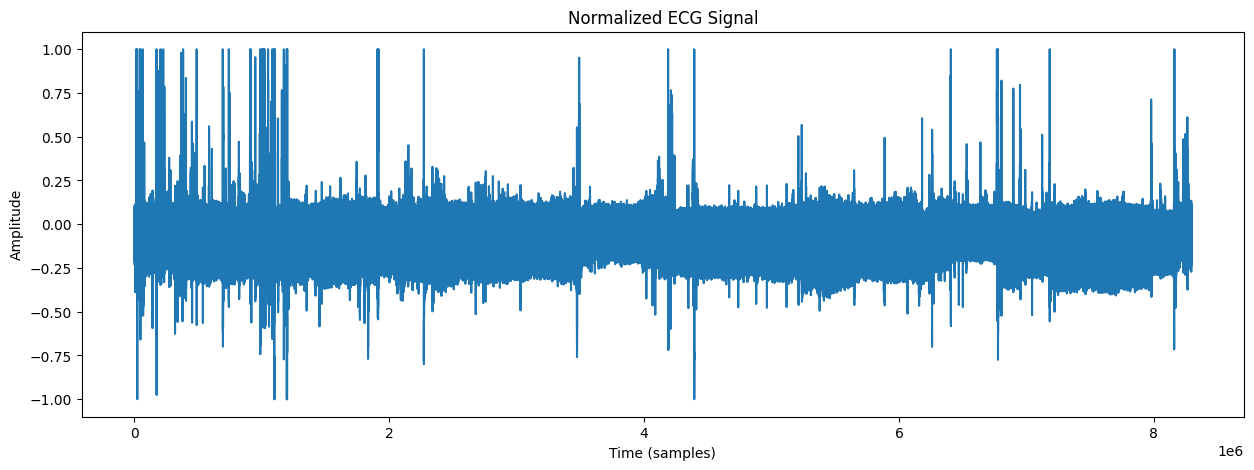

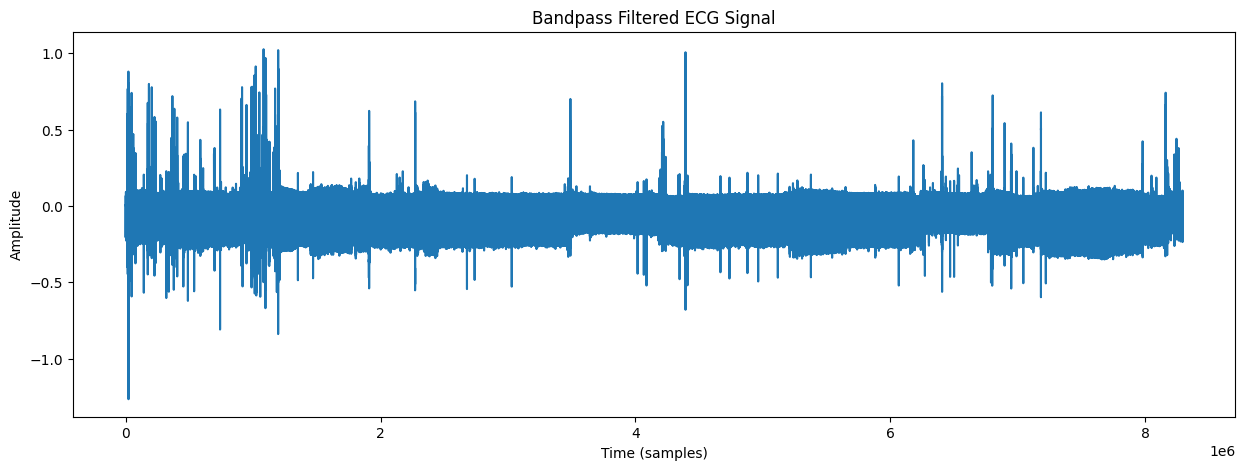

In [ ]:
# Extraction of the ecg from the edf file into a numpy array
edf_path = "f:/ProyectoPDS/data/data/mesa/polysomnography/edfs/mesa-sleep-0006.edf"

edf_array = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
channel = 'EKG'
ecg_signal = edf_array.get_data(picks=[channel])[0]

# Plot the signal
plt.figure(figsize=(15, 5))
plt.plot(ecg_signal)
plt.title('ECG Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

# Plot the normalized signal
ecg_signal_normalized = ecg_signal / (np.max(np.abs(ecg_signal)))

plt.figure(figsize=(15, 5))
plt.plot(ecg_signal_normalized)
plt.title('Normalized ECG Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

# Apply a bandpass filter and a notch filter to the signal
fs = edf_array.info['sfreq'] 
lowcut = 0.5  
highcut = 30.0

# Specifying order 4 makes a notch filter unnecesary as it will already attenuate frequencies the noise.
ecg_signal_bandpass = sgn.filtfilt(*sgn.butter(4, [lowcut / (0.5 * fs), highcut / (0.5 * fs)], btype='band'), ecg_signal_normalized)

plt.figure(figsize=(15, 5))
plt.plot(ecg_signal_bandpass)
plt.title('Bandpass Filtered ECG Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()
